# 05 · Human-on-the-loop · **Approval**

**Idea:** Before a risky/irreversible step, pause and ask a human: *approve*, or *reject with feedback*.

```
START -> draft_email -> human_approval --approve--> send_email -> END
              ^               |
              +---reject------+  (feedback goes back to the drafter)
```

## How human-in-the-loop works in LangGraph (read once)

1. A node calls **`interrupt(payload)`** → the graph **pauses** and saves its state to the **checkpointer**.
2. `graph.invoke(...)` returns right away with `"__interrupt__"` holding your payload (show it to the human).
3. Later, call `graph.invoke(Command(resume=<human answer>), config)` with the **same `thread_id`**.
4. The node **re-runs from its start**, and this time `interrupt(...)` *returns the human's answer*.

⚠️ Because the node restarts, put side-effects (sending email, charging cards) **after** the `interrupt()` call, never before.
A checkpointer + `thread_id` are mandatory — that's what remembers where the graph paused.

In [4]:
# --- Model setup -------------------------------------------------------------
# 1) Ollama must be running   ->  `ollama serve`  (the desktop app does this for you)
# 2) Pull the models once     ->  `ollama pull llama3.1`  and  `ollama pull qwen3:0.6b`
from langchain_ollama import ChatOllama

# llama3.1 (8B): our main "brain" - good at tool calling & structured output.
llm = ChatOllama(model="llama3.1", temperature=0)

# qwen3:0.6b: a tiny, very fast model - great for cheap jobs (classify, summarise, route).
# reasoning=False hides qwen3's <think> block so `.content` is just the answer.
small_llm = ChatOllama(model="qwen3:0.6b", temperature=0, reasoning=False)

In [5]:
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver   # stores checkpoints in RAM (use SqliteSaver/PostgresSaver in prod)

class State(TypedDict):
    request: str
    draft: str
    feedback: str
    status: str

In [10]:
def draft_email(state: State):
    prompt = f"Write a short, polite email (max 60 words) for this request: {state['request']}"
    if state.get("feedback"):   # second time around: include the human's feedback
        prompt += f"\n\nPrevious draft:\n{state['draft']}\n\nRewrite it following this feedback: {state['feedback']}"
    return {"draft": llm.invoke(prompt).content}


def human_approval(state: State) -> Command[Literal["send_email", "draft_email"]]:
    # PAUSE HERE. Whatever we pass to interrupt() is shown to the human.
    # When resumed, interrupt() returns the value the human sent back.
    decision = interrupt({"question": "Send this email?", "draft": state["draft"]})
    print(decision)
    print("----------------------")
    if decision == "approve":
        return Command(goto="send_email")
    # anything else is treated as feedback -> go back and rewrite
    return Command(goto="draft_email", update={"feedback": decision})


def send_email(state: State):
    print("📧 EMAIL SENT:\n", state["draft"])   # the irreversible action: only reached after approval
    return {"status": "sent"}

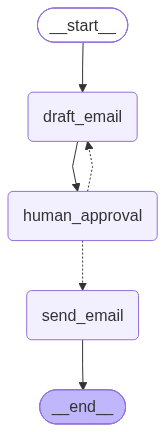

In [11]:
builder = StateGraph(State)
builder.add_node("draft_email", draft_email)
builder.add_node("human_approval", human_approval)
builder.add_node("send_email", send_email)
builder.add_edge(START, "draft_email")
builder.add_edge("draft_email", "human_approval")
builder.add_edge("send_email", END)        # human_approval routes itself via Command

graph = builder.compile(checkpointer=InMemorySaver())   # <- checkpointer is REQUIRED for interrupt()
from IPython.display import display, Image

# Visualize the agent's decision-making flow
display(Image(graph.get_graph().draw_mermaid_png()))

### Run it — first pass pauses at the approval step

In [12]:
config = {"configurable": {"thread_id": "email-1"}}     # the thread_id is the "save slot"

result = graph.invoke({"request": "Ask my manager for Friday off", "feedback": ""}, config)

print("⏸️  PAUSED. Human sees:")
print(result["__interrupt__"][0].value["draft"])
print("\nNext node to run:", graph.get_state(config).next)

⏸️  PAUSED. Human sees:
Here is a short, polite email:

Subject: Request for Friday Off

Dear [Manager's Name],

I am writing to request to take Friday off. I would greatly appreciate it if this could be approved. If there are any concerns or issues, please let me know and I will do my best to make arrangements.

Thank you for your time and consideration.

Best regards,
[Your Name]

Next node to run: ('human_approval',)


### Human says *no* and gives feedback → graph loops back, redrafts, pauses again

In [13]:
result = graph.invoke(Command(resume="Make it more formal and mention I'll finish my work beforehand"), config)
print("⏸️  PAUSED AGAIN with a revised draft:")
print(result["__interrupt__"][0].value["draft"])

Make it more formal and mention I'll finish my work beforehand
----------------------
⏸️  PAUSED AGAIN with a revised draft:
Here is a revised version of the email:

Subject: Request for Friday Off

Dear [Manager's Name],

I am writing to formally request to take Friday off. I will ensure that all my tasks are completed and my work is up to date prior to my departure. I would appreciate it if you could approve my request. Please let me know if there are any concerns.

Thank you for your consideration.

Best regards,
[Your Name]


### Human approves → the email is sent

In [14]:
result = graph.invoke(Command(resume="approve"), config)
print("status:", result["status"])

approve
----------------------
📧 EMAIL SENT:
 Here is a revised version of the email:

Subject: Request for Friday Off

Dear [Manager's Name],

I am writing to formally request to take Friday off. I will ensure that all my tasks are completed and my work is up to date prior to my departure. I would appreciate it if you could approve my request. Please let me know if there are any concerns.

Thank you for your consideration.

Best regards,
[Your Name]
status: sent


**In a real app** the `resume` value comes from a button click / Slack reaction / web form,
and `thread_id` is stored in your database so approval can happen hours later.